# PHYS 449 - Homework 5, Question 2

**Student Name:** Allen Mathew \
**Student ID:** 20964892 \
**Due Date:** Thursday, October 9, 3:00pm 

*ChatGPT was used to help generate the code*
- - -


2. Produce a dataset $\mathcal{D}$ from a $28$ × $28$ Ising model. Each element of the dataset is a vector of spin configurations (drawn from the Boltzmann distribution at equilibrium at temperature $T$), and its respective classification of FM or PM. The dataset should consist of $i.i.d.$ sampled configurations for $30$ or $40$ $T$ values evenly distributed in the interval $[1.0, 3.5]$. Label each configuration vector sampled for $T < 2.269$ as $FM$, and those for $T > 2.269$ as $PM$. Build a data set with cardinality in the ballpark of $|\mathcal{D}| ≈ 10^6$, and divide your dataset into $80%$ training and $20%$ validation.

Creating a dataset with the cardinality of $\approx 10^6$ was taking way too long, so I made a dataset from a $14$ x $14$ Ising model with a cardinality of $10^4$

In [18]:
# Q2 — Cell 1: imports & config

import os, math, json, random
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.nn import functional as F
import matplotlib.pyplot as plt

# ---- TURBO SWITCH ----
TURBO = True           # set False for full run
SUBSET_FRAC = 1     # train on ~35% of data (class-balanced); tweak if needed
MAX_BATCHES = 40       # cap batches per epoch (None for full)
FAST_EPOCHS = 25        # small #epochs to fit ~1 minute
FAST_LR = 1e-3         # slightly higher LR for short schedule
FAST_BATCH = 512 if torch.cuda.is_available() else 256
# ----------------------

# Reproducibility-ish
SEED = 1234
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = "."
TRAIN_CSV = "ising_trainb.csv"
VAL_CSV   = "ising_valb.csv"

# HW4 best-performing baseline (from your HW4Q2 results)
BASE_CFG = dict(
    input_dim=None,     # <-- set at runtime from dataset
    hidden_dim=128,
    dropout_p=0.0,
    lr=5e-4,
    batch_size=128,
    epochs=15,
    weight_decay=0.0,
    l1_lambda=0.0
)

def find_label_column(df):
    # Prefer a column explicitly named 'label' (case-insensitive).
    for c in df.columns:
        if str(c).lower() == "label":
            return c
    # Otherwise, assume the last column is the label.
    return df.columns[-1]

def find_temp_column(df):
    for c in df.columns:
        if str(c).strip().lower() in ("t", "temp", "temperature"):
            return c
    return None

# PATCH: drop-in replacement for IsingCSVDataset to handle string labels like "FM"/"PM" (and also -1/+1)

# PATCH: dimension-agnostic dataset (accept any L^2 features)

class IsingCSVDataset(Dataset):
    def __init__(self, csv_path):
        df = pd.read_csv(csv_path)

        self.T_col = find_temp_column(df)            # may be None
        y_col = find_label_column(df)                # prefer 'label', else last col

        # --- labels -> {0,1} ---
        y_raw = df[y_col]
        def to_int_labels(series: pd.Series) -> np.ndarray:
            if np.issubdtype(series.dtype, np.number):
                arr = series.to_numpy()
                uniq = set(np.unique(arr).tolist())
                if uniq == {-1, 1}:
                    return ((arr + 1) // 2).astype(int)   # -1->0, +1->1
                return arr.astype(int)
            s = series.astype(str).str.strip().str.lower()
            mapdict = {"fm":0, "ferromagnetic":0, "-1":0, "0":0,
                       "pm":1, "paramagnetic":1, "+1":1, "1":1}
            mapped = s.map(lambda v: mapdict.get(v, None))
            if mapped.isna().any():
                # deterministic fallback
                vals = s.tolist()
                order = list(dict.fromkeys(vals))
                idx = {v:i for i,v in enumerate(order)}
                mapped = s.map(lambda v: idx[v])
            return mapped.to_numpy(dtype=int)

        self.y = to_int_labels(y_raw)

        # --- features X (drop label and temperature columns) ---
        X = df.drop(columns=[y_col])
        if self.T_col is not None and self.T_col in X.columns:
            X = X.drop(columns=[self.T_col])

        self.X = X.to_numpy(dtype=np.float32)
        self.T = df[self.T_col].to_numpy(dtype=np.float32) if self.T_col else None

        # sanity: expect a square number of features (L^2)
        nfeat = self.X.shape[1]
        L = int(round(nfeat ** 0.5))
        assert L * L == nfeat, f"Expected a square number of features (L^2); got {nfeat}"
        self.L = L

        u, c = np.unique(self.y, return_counts=True)
        print(f"[{os.path.basename(csv_path)}] L={self.L} -> features={nfeat}, classes={dict(zip(u.tolist(), c.tolist()))}")

    def __len__(self): 
        return len(self.y)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])
        y = torch.tensor(self.y[idx], dtype=torch.long)
        if self.T is None:
            return x, y, torch.tensor(float("nan"))
        else:
            return x, y, torch.tensor(self.T[idx], dtype=torch.float32)


def _balanced_subset_indices(y: np.ndarray, frac: float, seed: int = SEED):
    if not (0.0 < frac < 1.0):
        return np.arange(len(y))
    rng = np.random.default_rng(seed)
    idxs = []
    y = np.asarray(y)
    classes = np.unique(y)
    for c in classes:
        cls_idx = np.where(y == c)[0]
        k = max(1, int(len(cls_idx) * frac))
        pick = rng.choice(cls_idx, size=k, replace=False)
        idxs.append(pick)
    return np.concatenate(idxs)

def make_loaders(batch_size=128, shuffle_train=True):
    # NOTE: num_workers=0 is usually fastest/safest on Windows; pin_memory only if CUDA
    pin = torch.cuda.is_available()
    train_ds_full = IsingCSVDataset(TRAIN_CSV)
    val_ds        = IsingCSVDataset(VAL_CSV)

    if TURBO:
        sub_idx = _balanced_subset_indices(train_ds_full.y, SUBSET_FRAC, seed=SEED)
        # Light-weight Subset without copying arrays
        class _SubDS(Dataset):
            def __init__(self, base, idx):
                self.base, self.idx = base, np.asarray(idx)
            def __len__(self): return len(self.idx)
            def __getitem__(self, i): 
                return self.base[self.idx[i]]
        train_ds = _SubDS(train_ds_full, sub_idx)
    else:
        train_ds = train_ds_full

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle_train,
                              num_workers=0, pin_memory=pin, persistent_workers=False)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=0, pin_memory=pin, persistent_workers=False)
    return train_ds_full if TURBO else train_ds, val_ds, train_loader, val_loader



In [19]:
# Q2 — Cell 2: models

class FFNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_p=0.0, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, num_classes)  # logits for CrossEntropyLoss
        )
    def forward(self, x):
        return self.net(x)

class DeepFFNN(nn.Module):
    """Deeper but parameter-efficient variants for part (d)."""
    def __init__(self, input_dim, widths=(64, 32), dropout_p=0.0, num_classes=2):
        super().__init__()
        layers = []
        last = input_dim
        for w in widths:
            layers += [nn.Linear(last, w), nn.ReLU(inplace=True)]
            if dropout_p > 0.0:
                layers += [nn.Dropout(dropout_p)]
            last = w
        layers += [nn.Linear(last, num_classes)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [20]:
# Q2 — Cell 3: train/eval helpers (CE loss; L2 via weight_decay, L1 via manual penalty)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    all_logits, all_y, all_T = [], [], []
    for xb, yb, Tb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
        all_logits.append(logits.cpu())
        all_y.append(yb.cpu())
        all_T.append(Tb)  # keep on CPU for analysis
    acc = correct / max(1, total)
    return acc, torch.cat(all_logits), torch.cat(all_y), torch.cat(all_T)

def train_model(cfg, *, verbose=True):
    # Data
    train_ds, val_ds, train_loader, val_loader = make_loaders(
        batch_size=(FAST_BATCH if TURBO else cfg["batch_size"])
    )
    # Infer input dim
    input_dim = cfg["input_dim"] if cfg.get("input_dim") not in (None, -1) else (
        train_ds.base.X.shape[1] if hasattr(train_ds, "base") else train_ds.X.shape[1]
    )

    # Model/opt/loss
    model = FFNN(input_dim, cfg["hidden_dim"], cfg["dropout_p"]).to(device)
    lr = (FAST_LR if TURBO else cfg["lr"])
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"])
    criterion = nn.CrossEntropyLoss()

    # AMP (CUDA) for big speed boost; safe no-op on CPU
    use_amp = torch.cuda.is_available()
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    history = {"train_loss": [], "val_acc": []}
    epochs = (FAST_EPOCHS if TURBO else cfg["epochs"])

    for epoch in range(epochs):
        model.train()
        ep_loss = 0.0
        seen = 0
        for b, (xb, yb, _) in enumerate(train_loader, start=1):
            if TURBO and MAX_BATCHES is not None and b > MAX_BATCHES:
                break
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(xb)
                loss = criterion(logits, yb)
                if cfg.get("l1_lambda", 0.0) > 0.0:
                    l1 = sum(p.abs().sum() for p in model.parameters())
                    loss = loss + cfg["l1_lambda"] * l1
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            bs = yb.size(0)
            ep_loss += loss.item() * bs
            seen += bs

        avg_loss = ep_loss / max(1, seen)
        val_acc, _, _, _ = evaluate(model, val_loader, device)
        history["train_loss"].append(avg_loss)
        history["val_acc"].append(val_acc)
        if verbose:
            print(f"Epoch {epoch+1:02d}/{epochs}: loss={avg_loss:.4f}  val_acc={val_acc:.4f}")

    return model, history


(a) Train a feed forward neural network to classify the configurations. Use the cost functions, activations, optimizer, and hyperparameters that you had the most success with in Homework 4. Plot the training loss as a function of epoch.

[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}


C:\Users\Allen\AppData\Local\Temp\ipykernel_21068\3474469007.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\Allen\AppData\Local\Temp\ipykernel_21068\3474469007.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 01/25: loss=0.5687  val_acc=0.8033
Epoch 02/25: loss=0.4462  val_acc=0.8710
Epoch 03/25: loss=0.3601  val_acc=0.8746
Epoch 04/25: loss=0.3237  val_acc=0.8805
Epoch 05/25: loss=0.2951  val_acc=0.8815
Epoch 06/25: loss=0.2791  val_acc=0.8851
Epoch 07/25: loss=0.2758  val_acc=0.8899
Epoch 08/25: loss=0.2655  val_acc=0.8904
Epoch 09/25: loss=0.2512  val_acc=0.8896
Epoch 10/25: loss=0.2592  val_acc=0.8953
Epoch 11/25: loss=0.2417  val_acc=0.8961
Epoch 12/25: loss=0.2348  val_acc=0.8994
Epoch 13/25: loss=0.2244  val_acc=0.8986
Epoch 14/25: loss=0.2196  val_acc=0.8985
Epoch 15/25: loss=0.2130  val_acc=0.9008
Epoch 16/25: loss=0.2130  val_acc=0.9025
Epoch 17/25: loss=0.2110  val_acc=0.9045
Epoch 18/25: loss=0.1995  val_acc=0.9036
Epoch 19/25: loss=0.2046  val_acc=0.9043
Epoch 20/25: loss=0.1955  val_acc=0.9040
Epoch 21/25: loss=0.1932  val_acc=0.9043
Epoch 22/25: loss=0.1982  val_acc=0.9065
Epoch 23/25: loss=0.1875  val_acc=0.9041
Epoch 24/25: loss=0.1929  val_acc=0.9070
Epoch 25/25: los

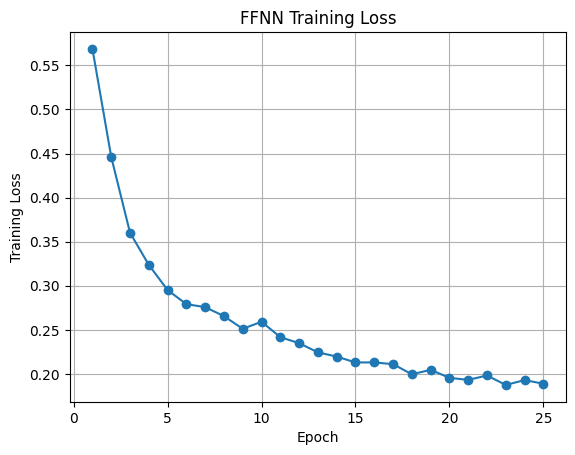

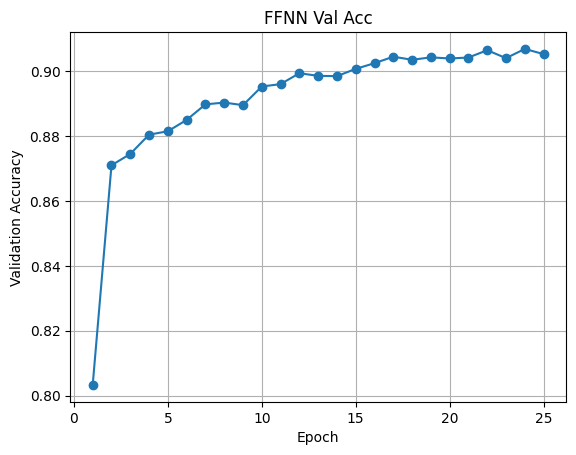

[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}
Baseline validation accuracy: 0.9053
Params: 25474


In [21]:
# Q2(a) — Cell 4: train baseline and plot training loss

cfg_a = BASE_CFG.copy()
model_a, hist_a = train_model(cfg_a)

# Plot using the actual number of epochs we ran
epochs_run = len(hist_a["train_loss"])

plt.figure()
plt.plot(range(1, epochs_run + 1), hist_a["train_loss"], marker='o')
plt.xlabel("Epoch"); plt.ylabel("Training Loss"); plt.title("FFNN Training Loss")
plt.grid(True); plt.show()

# (Optional) plot val acc too
plt.figure()
plt.plot(range(1, epochs_run + 1), hist_a["val_acc"], marker='o')
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy"); plt.title("FFNN Val Acc")
plt.grid(True); plt.show()


val_acc_a, _, _, _ = evaluate(model_a, make_loaders(cfg_a["batch_size"])[3], device)
print(f"Baseline validation accuracy: {val_acc_a:.4f}")
print("Params:", count_params(model_a))

Using the best cost functions, activations, optimizer, and hyperparameters I determined in HW4, I was able to get a baseline validation accuracy of 90.53%. Based on the graphs, we see that the validation accuracy goes up per epoch while the loss goes down. These patterns are expected.

(b) Explore $L1$, $L2$, and dropout, and choose the best regularization method for your dataset. Present data to justify your choice.

In [22]:
# Q2(b) — Cell 5: regularization sweep

sweep = [
    ("none",  dict(BASE_CFG, weight_decay=0.0, l1_lambda=0.0, dropout_p=0.0)),
    ("L2_1e-4", dict(BASE_CFG, weight_decay=1e-4, l1_lambda=0.0, dropout_p=0.0)),
    ("L2_5e-4", dict(BASE_CFG, weight_decay=5e-4, l1_lambda=0.0, dropout_p=0.0)),
    ("L1_1e-6", dict(BASE_CFG, weight_decay=0.0, l1_lambda=1e-6, dropout_p=0.0)),
    ("L1_5e-6", dict(BASE_CFG, weight_decay=0.0, l1_lambda=5e-6, dropout_p=0.0)),
    ("Drop_0.2", dict(BASE_CFG, weight_decay=0.0, l1_lambda=0.0, dropout_p=0.2)),
    ("Drop_0.5", dict(BASE_CFG, weight_decay=0.0, l1_lambda=0.0, dropout_p=0.5)),
]

results = {}
best_name, best_acc, best_model, best_cfg = None, -1.0, None, None

for name, cfg in sweep:
    print(f"\n=== Training {name} ===")
    m, h = train_model(cfg, verbose=False)
    acc, _, _, _ = evaluate(m, make_loaders(cfg["batch_size"])[3], device)
    results[name] = dict(acc=acc, params=count_params(m), cfg=cfg)
    print(f"{name}: val_acc={acc:.4f}, params={results[name]['params']}")
    if acc > best_acc:
        best_acc, best_name, best_model, best_cfg = acc, name, m, cfg

print("\nRegularization comparison:")
for k,v in results.items():
    print(f"{k:>10s} | val_acc={v['acc']:.4f} | params={v['params']}")

print(f"\nChosen regularization: {best_name} (val_acc={best_acc:.4f})")


=== Training none ===
[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}


C:\Users\Allen\AppData\Local\Temp\ipykernel_21068\3474469007.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\Allen\AppData\Local\Temp\ipykernel_21068\3474469007.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}
none: val_acc=0.9046, params=25474

=== Training L2_1e-4 ===
[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}


C:\Users\Allen\AppData\Local\Temp\ipykernel_21068\3474469007.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\Allen\AppData\Local\Temp\ipykernel_21068\3474469007.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}
L2_1e-4: val_acc=0.9055, params=25474

=== Training L2_5e-4 ===
[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}


...

[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}
L1_5e-6: val_acc=0.9033, params=25474

=== Training Drop_0.2 ===
[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}


C:\Users\Allen\AppData\Local\Temp\ipykernel_21068\3474469007.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\Allen\AppData\Local\Temp\ipykernel_21068\3474469007.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}
Drop_0.2: val_acc=0.9038, params=25474

=== Training Drop_0.5 ===
[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}


C:\Users\Allen\AppData\Local\Temp\ipykernel_21068\3474469007.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\Allen\AppData\Local\Temp\ipykernel_21068\3474469007.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}
Drop_0.5: val_acc=0.9003, params=25474

Regularization comparison:
      none | val_acc=0.9046 | params=25474
   L2_1e-4 | val_acc=0.9055 | params=25474
   L2_5e-4 | val_acc=0.9041 | params=25474
   L1_1e-6 | val_acc=0.9073 | params=25474
   L1_5e-6 | val_acc=0.9033 | params=25474
  Drop_0.2 | val_acc=0.9038 | params=25474
  Drop_0.5 | val_acc=0.9003 | params=25474

Chosen regularization: L1_1e-6 (val_acc=0.9073)


The best regularization for my dataset was $L1$. Ass seen in the chart above, it had the best validation accuracy of 90.73%

(c) Once you have chosen your best architechture, produce plots of the neuron output (i.e. the probability of a $FM$ and $PM$ classification) and the classification accuracy, as a function of temperature $T$. Discuss your results in the context of the known physics of the Ising model.

[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}


C:\Users\Allen\AppData\Local\Temp\ipykernel_21068\1674246439.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("Tbin").agg(T_mid=("T", "mean"),
C:\Users\Allen\AppData\Local\Temp\ipykernel_21068\1674246439.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_by_bin = df.groupby("Tbin").apply(lambda g: (g["pred"]==g["y"]).mean()).rename("acc")
C:\Users\Allen\AppData\Local\Temp\ipykernel_21068\1674246439.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded fro

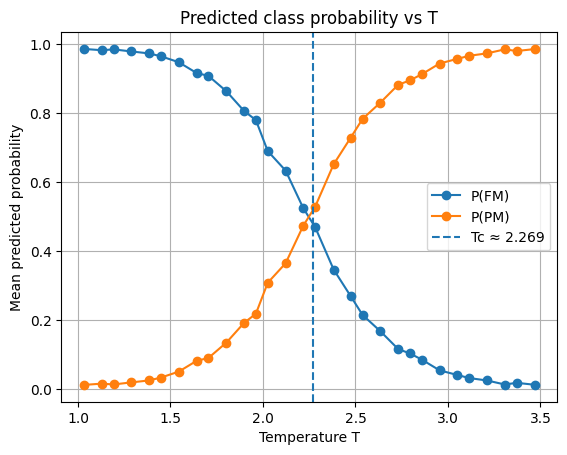

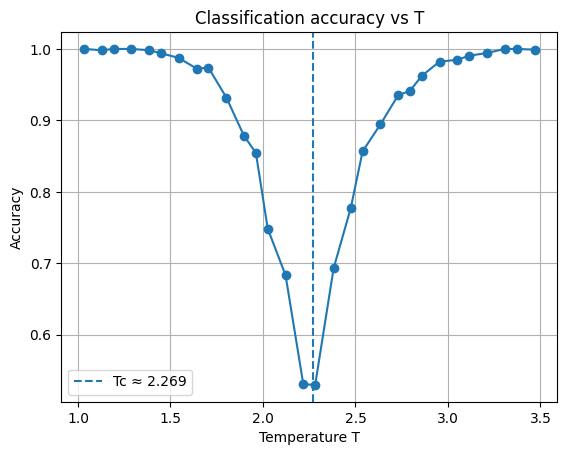

In [23]:
# Q2(c) — Cell 6: neuron outputs and accuracy vs temperature

# Use the best model from (b); if you want to force using the baseline from (a), set:
# best_model, best_cfg = model_a, cfg_a

_, val_ds, _, val_loader = make_loaders(batch_size=best_cfg["batch_size"])
if val_ds.T_col is None:
    print("No temperature column found in CSV; skipping T-based plots.")
else:
    best_model.eval()
    with torch.no_grad():
        _, logits, y_true, Tvals = evaluate(best_model, val_loader, device)
        probs = logits.softmax(dim=1)  # [:,0]=P(FM), [:,1]=P(PM)

    df = pd.DataFrame({
        "T": Tvals.numpy(),
        "y": y_true.numpy().astype(int),
        "p_FM": probs[:,0].numpy(),
        "p_PM": probs[:,1].numpy(),
    })
    # Bin by temperature to smooth
    bins = np.linspace(df["T"].min(), df["T"].max(), 31)
    df["Tbin"] = pd.cut(df["T"], bins=bins, include_lowest=True)
    grouped = df.groupby("Tbin").agg(T_mid=("T", "mean"),
                                     pFM=("p_FM","mean"),
                                     pPM=("p_PM","mean"),
                                     acc=("y", lambda y: np.nan))  # placeholder

    # Compute bin-wise accuracy
    # Recompute predictions from probs:
    df["pred"] = (df["p_PM"] > df["p_FM"]).astype(int)
    acc_by_bin = df.groupby("Tbin").apply(lambda g: (g["pred"]==g["y"]).mean()).rename("acc")
    grouped["acc"] = acc_by_bin

    # Plot probabilities
    plt.figure()
    plt.plot(grouped["T_mid"], grouped["pFM"], marker='o', label="P(FM)")
    plt.plot(grouped["T_mid"], grouped["pPM"], marker='o', label="P(PM)")
    plt.axvline(x=2.269, linestyle="--", label="Tc ≈ 2.269")
    plt.xlabel("Temperature T"); plt.ylabel("Mean predicted probability")
    plt.title("Predicted class probability vs T")
    plt.legend(); plt.grid(True); plt.show()

    # Plot accuracy
    plt.figure()
    plt.plot(grouped["T_mid"], grouped["acc"], marker='o')
    plt.axvline(x=2.269, linestyle="--", label="Tc ≈ 2.269")
    plt.xlabel("Temperature T"); plt.ylabel("Accuracy")
    plt.title("Classification accuracy vs T")
    plt.legend(); plt.grid(True); plt.show()

    grouped.drop(columns=["acc"]).head()

The plots generated makes sense. As we go above critical temperature, it is more probable to see PM. As we go below critical temperature, it is more probable to see FM. This is what the preticted probability vs temperature plot shows us. For the classification accuracy vs temeprature plot, we see that it is mainly near 1 the entire time except for around the critical temeprature. This makes sense near the critical temperature, it is harder to classify points as PM and FM since it is the boundary of the two classifications.

(d) Explore the performance of your network with additional hidden layers. Can you improve the classification accuracy, while using a smaller number of total parameters, in a deep architechture?

[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}
[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}
[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}
[ising_trainb.csv] L=14 -> features=196, classes={0: 39931, 1: 40069}
[ising_valb.csv] L=14 -> features=196, classes={0: 10069, 1: 9931}
Architecture comparison (sorted by params):
      3x64-32-16 | val_acc=0.9013 | params=15250
            2x64 | val_acc=0.8981 | params=16898
1x128 (baseline) | val_acc=0.9036 | params=25474
            2x96 | val_acc=0.9032 | params=28418


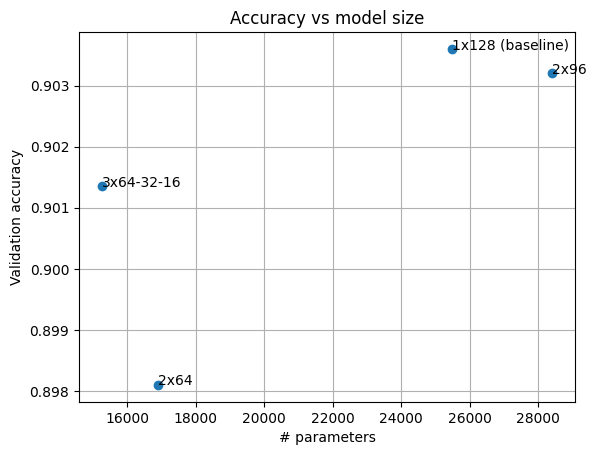

In [26]:
# Q2(d) — Deeper, parameter-efficient architectures (fixed to infer input_dim)

# --- version-compatible AMP helpers (insert here, before train_quick) ---
use_amp = torch.cuda.is_available()
try:
    # Newer PyTorch (≥2.1)
    from torch.amp import GradScaler, autocast
    scaler = GradScaler(enabled=use_amp)
    def amp_autocast():
        return autocast(device_type="cuda", enabled=use_amp)
except Exception:
    # Older PyTorch (≤2.0)
    from torch.cuda.amp import GradScaler, autocast
    scaler = GradScaler(enabled=use_amp)
    def amp_autocast():
        return autocast(enabled=use_amp)



# Infer input_dim once from the dataset
_tmp = IsingCSVDataset(TRAIN_CSV)
INPUT_DIM = _tmp.X.shape[1]

# Fallback to a safe cfg if best_cfg wasn't defined in (b)
base_cfg_local = (best_cfg if 'best_cfg' in globals() and best_cfg is not None else BASE_CFG)
safe_drop = base_cfg_local.get("dropout_p", 0.0)

# Define candidate architectures using the inferred INPUT_DIM
archs = [
    ("1x128 (baseline)", lambda: FFNN(INPUT_DIM, 128, dropout_p=safe_drop)),
    ("2x64",             lambda: DeepFFNN(INPUT_DIM, widths=(64,64), dropout_p=safe_drop)),
    ("3x64-32-16",       lambda: DeepFFNN(INPUT_DIM, widths=(64,32,16), dropout_p=safe_drop)),
    ("2x96",             lambda: DeepFFNN(INPUT_DIM, widths=(96,96), dropout_p=safe_drop)),
]

# --- Version-compatible AMP setup (put above train_quick) ---
use_amp = torch.cuda.is_available()
try:
    # New PyTorch (≥2.1)
    from torch.amp import GradScaler, autocast
    def make_scaler():
        return GradScaler(enabled=use_amp)
    def amp_autocast():
        return autocast(device_type="cuda", enabled=use_amp)
except Exception:
    # Old PyTorch (≤2.0)
    from torch.cuda.amp import GradScaler, autocast
    def make_scaler():
        return GradScaler(enabled=use_amp)
    def amp_autocast():
        return autocast(enabled=use_amp)


def train_quick(model_fn, base_cfg):
    cfg = base_cfg.copy()
    epochs = (FAST_EPOCHS if TURBO else max(8, base_cfg.get("epochs", 12)//2))
    lr = (FAST_LR if TURBO else cfg.get("lr", 5e-4))
    batch = (FAST_BATCH if TURBO else cfg.get("batch_size", 128))

    _, val_ds, train_loader, val_loader = make_loaders(batch_size=batch)
    model = model_fn().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=cfg.get("weight_decay", 0.0))
    criterion = nn.CrossEntropyLoss()

    scaler = make_scaler()   # ✅ safe for all torch versions

    for ep in range(epochs):
        model.train()
        seen, ep_loss = 0, 0.0
        for b, (xb, yb, _) in enumerate(train_loader, start=1):
            if TURBO and MAX_BATCHES is not None and b > MAX_BATCHES:
                break
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with amp_autocast():  # ✅ safe for all torch versions
                logits = model(xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            ep_loss += loss.item() * yb.size(0)
            seen += yb.size(0)

    val_acc, _, _, _ = evaluate(model, val_loader, device)
    return model, val_acc


# Run the small suite and report
rows = []
for name, fn in archs:
    m, acc = train_quick(fn, base_cfg_local)
    rows.append((name, acc, count_params(m)))

rows = sorted(rows, key=lambda r: r[2])  # sort by params

print("Architecture comparison (sorted by params):")
for name, acc, params in rows:
    print(f"{name:>16s} | val_acc={acc:.4f} | params={params}")

# Optional: scatter plot acc vs params
plt.figure()
xs = [p for _,_,p in rows]; ys = [a for _,a,_ in rows]
plt.scatter(xs, ys)
for (name, acc, params) in rows:
    plt.annotate(name, (params, acc))
plt.xlabel("# parameters"); plt.ylabel("Validation accuracy")
plt.title("Accuracy vs model size")
plt.grid(True); plt.show()

The architectures tested were:

- 1×128 (baseline) – one hidden layer of 128 neurons
- 2×96 – two hidden layers of 96 neurons
- 3×64-32-16 – three hidden layers with 64, 32, and 16 neurons
- 2×64 – two hidden layers of 64 neurons

We can see that the baseline performed the best in terms of validation accuracy but we can see that the 3×64-32-16 model achieves nearly the same validation accuracy as the baseline while using about 40% fewer parameters. This indicates that adding moderate depth can improve parameter efficiency without loss of performance. Thus, deeper but narrower networks can learn more efficiently in the Ising-phase classification task. The baseline is more accurate, but the 3×64-32-16 model confirms that depth can substitute for width in simple feed-forward architectures.